In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import sklearn
from sklearn import metrics
from sklearn.neighbors import KNeighborsRegressor
from scipy.cluster.vq import kmeans, vq, whiten
from scipy.spatial.distance import cdist
import numpy as np
from datetime import datetime

In [20]:
elec_all_data = pd.read_csv("../data/meters/cleaned/electricity_cleaned.csv", index_col='timestamp', parse_dates=True)
elec_all_data.head()

,Panther_parking_Lorriane,Panther_lodging_Cora,Panther_office_Hannah,Panther_lodging_Hattie,Panther_education_Teofila,Panther_education_Jerome,Panther_retail_Felix,Panther_parking_Asia,Panther_education_Misty,Panther_retail_Gilbert,...,Cockatoo_public_Caleb,Cockatoo_education_Tyler,Cockatoo_public_Shad,Mouse_health_Buddy,Mouse_health_Modesto,Mouse_lodging_Vicente,Mouse_health_Justin,Mouse_health_Ileana,Mouse_health_Estela,Mouse_science_Micheal
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,123.200,727.575,69.200,8.8224,370.0870,10.0,282.9965,26.0,135.0,168.2243
2016-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,126.475,731.200,66.275,17.6449,737.8260,30.0,574.9265,51.0,265.0,336.4486
2016-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,127.825,724.675,64.675,17.6449,729.9255,30.0,570.2780,50.0,272.0,336.4486
2016-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,130.475,737.375,65.875,17.6449,722.2620,20.0,561.1470,52.0,276.0,336.4486
2016-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,129.675,721.150,66.275,17.6449,719.1665,30.0,564.3695,50.0,280.0,336.4486


In [21]:
pd.set_option('display.max_rows', None)
education_cols = elec_all_data.columns[elec_all_data.columns.str.contains("education")]
print(education_cols.tolist())
print(f"\n共筛选出 {len(education_cols)} 个教学楼列名")

['Panther_education_Teofila', 'Panther_education_Jerome', 'Panther_education_Misty', 'Panther_education_Tina', 'Panther_education_Janis', 'Panther_education_Quintin', 'Panther_education_Violet', 'Panther_education_Edna', 'Panther_education_Sophia', 'Panther_education_Hugh', 'Panther_education_Annetta', 'Panther_education_Ivan', 'Panther_education_Alecia', 'Panther_education_Rosalie', 'Panther_education_Jonathan', 'Panther_education_Neal', 'Panther_education_Mohammad', 'Panther_education_Enriqueta', 'Panther_education_Shelton', 'Panther_education_Aurora', 'Panther_education_Vincent', 'Panther_education_Mattie', 'Panther_education_Genevieve', 'Panther_education_Diann', 'Panther_education_Emily', 'Panther_education_Scarlett', 'Panther_education_Zelda', 'Panther_education_Gina', 'Panther_education_Karri', 'Panther_education_Cleopatra', 'Robin_education_Zenia', 'Robin_education_Derick', 'Robin_education_Della', 'Robin_education_Leslie', 'Robin_education_Mercedes', 'Robin_education_Julius', 

In [22]:
table = ["Panther_education_Ivan","Moose_education_Ricardo","Crow_education_Winston","Cockatoo_education_Erik"]# 关键：method='time' 基于时间间隔插值
education_1 = pd.DataFrame(elec_all_data["Panther_education_Ivan"].truncate(before='2016-06-01').interpolate(method='time') ) 
education_2 = pd.DataFrame(elec_all_data["Moose_education_Ricardo"].truncate(before='2016-01-10').interpolate(method='time')  )
education_3 = pd.DataFrame(elec_all_data["Crow_education_Winston"].truncate(before='2016-01-15',after='2017-10-31').interpolate(method='time')  )
education_4 = pd.DataFrame(elec_all_data["Cockatoo_education_Erik"].truncate(before='2016-04-01', after='2018-12-20').interpolate(method='time')  )
education = pd.concat([education_1, education_2, education_3, education_4], axis=1)
education.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17328 entries, 2016-01-10 00:00:00 to 2017-12-31 23:00:00
Freq: h
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Panther_education_Ivan   13896 non-null  float64
 1   Moose_education_Ricardo  17328 non-null  float64
 2   Crow_education_Winston   15721 non-null  float64
 3   Cockatoo_education_Erik  15360 non-null  float64
dtypes: float64(4)
memory usage: 676.9 KB


In [23]:
weather_data = pd.read_csv("../data/weather/weather.csv", index_col='timestamp', parse_dates=True)
weather_data.head(1)

,site_id,airTemperature,cloudCoverage,dewTemperature,precipDepth1HR,precipDepth6HR,seaLvlPressure,windDirection,windSpeed
timestamp,,,,,,,,,
2016-01-01,Panther,19.4,NaN,19.4,0.0,NaN,NaN,0.0,0.0


In [24]:
# 获取所有唯一的站点名称
unique_sites = weather_data['site_id'].unique()
# 统计站点数量
site_count = len(unique_sites)

print("所有站点：", unique_sites)
print("站点数量：", site_count)

所有站点： ['Panther' 'Robin' 'Fox' 'Rat' 'Bear' 'Lamb' 'Peacock' 'Moose' 'Gator'
 'Bull' 'Bobcat' 'Crow' 'Shrew' 'Swan' 'Wolf' 'Hog' 'Eagle' 'Cockatoo'
 'Mouse']
站点数量： 19


In [25]:
table=[1,2,4,8]
weather_data_Panther = weather_data[weather_data.site_id == 'Panther']
weather_data_Panther = weather_data_Panther.iloc[:,table].truncate(before='2016-06-01')

weather_data_Moose = weather_data[weather_data.site_id == 'Moose']
weather_data_Moose = weather_data_Moose.iloc[:,table].truncate(before='2016-01-10')

weather_data_Crow = weather_data[weather_data.site_id == 'Crow']
weather_data_Crow = weather_data_Crow.iloc[:,table].truncate(before='2016-01-15',after='2017-10-31')

weather_data_Cockatoo = weather_data[weather_data.site_id == 'Cockatoo']
weather_data_Cockatoo = weather_data_Cockatoo.iloc[:, table].truncate(
    before='2016-04-01',  # 不早于 2016年4月1日（包含这一天）
    after='2018-12-20'    # 不晚于 2018年1月31日（包含这一天）
)


cols_to_drop = weather_data_Crow.columns[[1, 2]]
weather_data_Crow.drop(columns=cols_to_drop, inplace=True)
weather_data_Panther.drop(columns=cols_to_drop, inplace=True)
weather_data_Moose.drop(columns=cols_to_drop, inplace=True)
weather_data_Moose.head(5)

,airTemperature,windSpeed
timestamp,,
2016-01-10 00:00:00,1.8,2.1
2016-01-10 01:00:00,1.8,2.1
2016-01-10 02:00:00,2.4,3.1
2016-01-10 03:00:00,2.3,4.1
2016-01-10 04:00:00,1.9,3.6


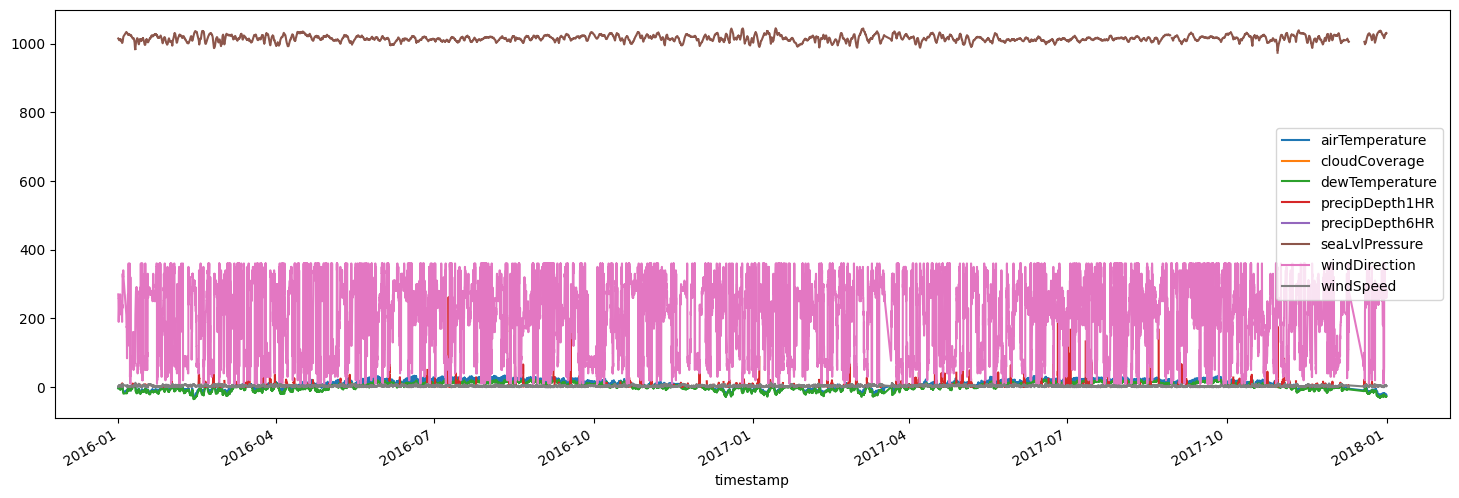

In [26]:
Crow_h = weather_data[weather_data.site_id == 'Crow']  # 假设筛选后是 DataFrame
plt.figure(figsize=(18, 6))
Crow_h.plot(ax=plt.gca())  # 使用 DataFrame 的 plot 方法，指定当前 axes
plt.show()  # 显示图像

In [27]:
Panther_hourly = weather_data_Panther.resample("h").mean()
Moose_hourly = weather_data_Moose.resample("h").mean()
Crow_hourly = weather_data_Crow.resample("h").mean()
Cockatoo_hourly = weather_data_Cockatoo.resample("h").mean()


In [28]:
Panther_shuju = pd.concat([ education_1,Panther_hourly],  axis=1) 
Moose_shuju = pd.concat([ education_2, Moose_hourly],  axis=1)
Crow_shuju = pd.concat([ education_3, Crow_hourly],  axis=1)
Cockatoo_shuju = pd.concat([ education_4, Cockatoo_hourly],  axis=1)


In [29]:
# 导出 Panther 站点的数据为 CSV
Panther_shuju.to_csv('Panther_data.csv', index=True)  # index=True 保留时间戳索引

Moose_shuju.to_csv('Moose_data.csv', index=True)

Crow_shuju.to_csv('Crow_data.csv', index=True)

Cockatoo_shuju.to_csv('Cockatoo_data.csv', index=True)

In [30]:
Crow_shuju.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 15721 entries, 2016-01-15 00:00:00 to 2017-10-31 00:00:00
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Crow_education_Winston  15721 non-null  float64
 1   airTemperature          15351 non-null  float64
 2   windSpeed               15351 non-null  float64
dtypes: float64(3)
memory usage: 1007.3 KB
